<a href="https://colab.research.google.com/github/alexis2487/Data_Analyst_Google_Colab/blob/main/Data_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [3]:
pinguinos =sns.load_dataset("penguins")
vuelos = sns.load_dataset("flights")
titanic = sns.load_dataset("titanic")
accidentes = sns.load_dataset("car_crashes")
resonancia = sns.load_dataset("fmri")
diamantes = sns.load_dataset("diamonds")

In [4]:
pinguinos.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [5]:
# 1. Usando el dataset de pingüinos, calcula el promedio del largo del pico:

In [6]:
promedio_pico_especies = pinguinos.groupby('species')['bill_length_mm'].mean().reset_index()
promedio_pico_especies

,species,bill_length_mm
0,Adelie,38.791391
1,Chinstrap,48.833824
2,Gentoo,47.504878


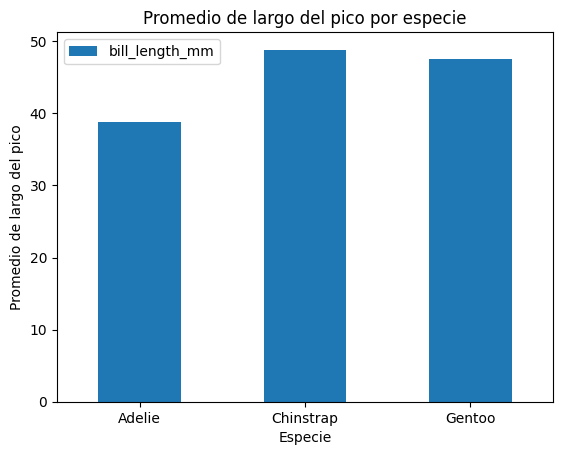

In [7]:
promedio_pico_especies.plot.bar(x="species", y="bill_length_mm")
plt.title("Promedio de largo del pico por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio de largo del pico")
plt.xticks(rotation=0)
plt.show()

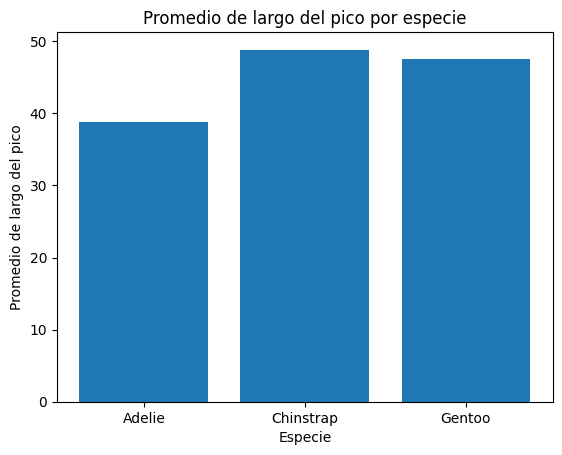

In [8]:
#plt.bar(average_bill_length_by_species.index, average_bill_length_by_species.values)
plt.bar(promedio_pico_especies["species"], promedio_pico_especies["bill_length_mm"])
plt.title("Promedio de largo del pico por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio de largo del pico")
plt.xticks(rotation=0)
plt.show()

Text(0.5, 1.0, 'Promedio de largo del pico por especie')

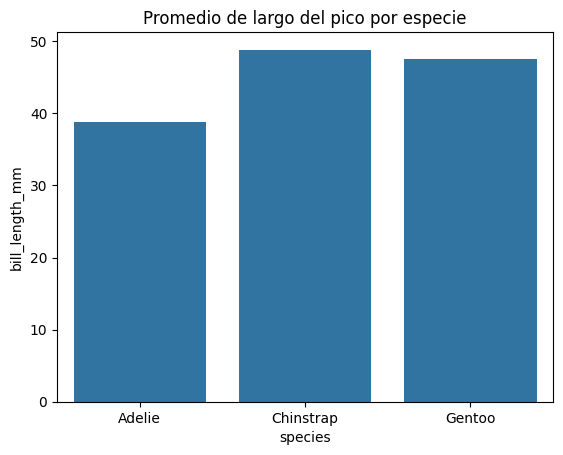

In [9]:
sns.barplot(promedio_pico_especies, x="species", y='bill_length_mm')
plt.title("Promedio de largo del pico por especie")

In [10]:
grafico =px.bar(promedio_pico_especies, x="species", y='bill_length_mm')
grafico.show()

In [11]:
# 2. Usando el dataset de vuelos, calcula el total de pasajeros por año

In [12]:
pasajeros_por_año = vuelos.groupby('year')['passengers'].sum().reset_index()
pasajeros_por_año.head()

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700


<Axes: xlabel='year'>

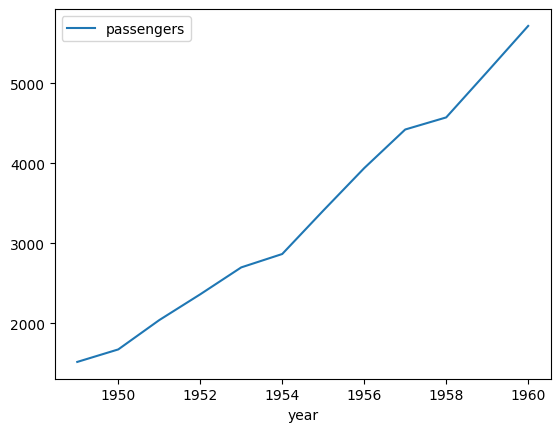

In [13]:
pasajeros_por_año.plot.line(x="year", y="passengers")

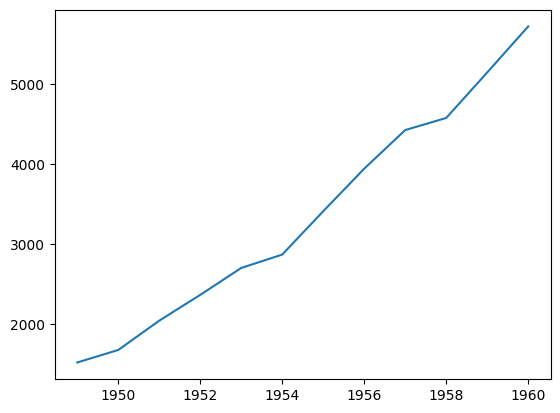

In [14]:
plt.plot(pasajeros_por_año["year"], pasajeros_por_año["passengers"])
plt.show()

<Axes: xlabel='year', ylabel='passengers'>

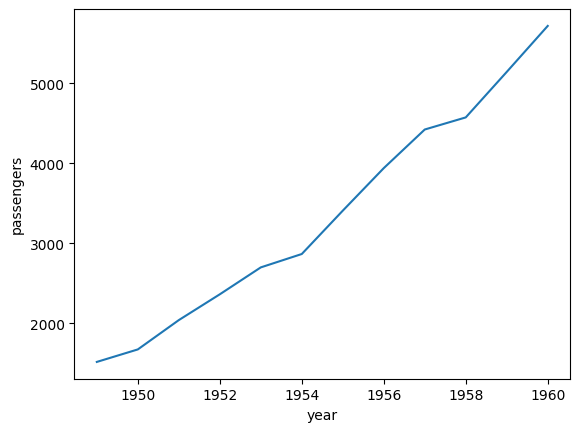

In [15]:
sns.lineplot(pasajeros_por_año, x="year", y="passengers")

In [16]:
grafico = px.line(pasajeros_por_año, x="year", y="passengers")
grafico.show()

In [17]:
# 3. Usando el dataset de pingüinos realiza los siguientes gráficos de dispersión mostrando el tamaño del pico vs la profundidad del pico.

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

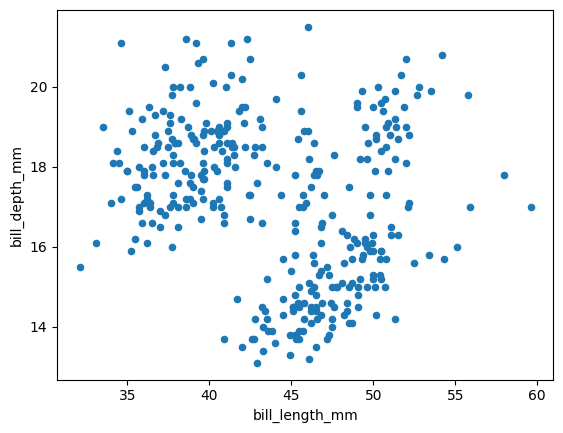

In [18]:
pinguinos.plot.scatter(x="bill_length_mm", y="bill_depth_mm")

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

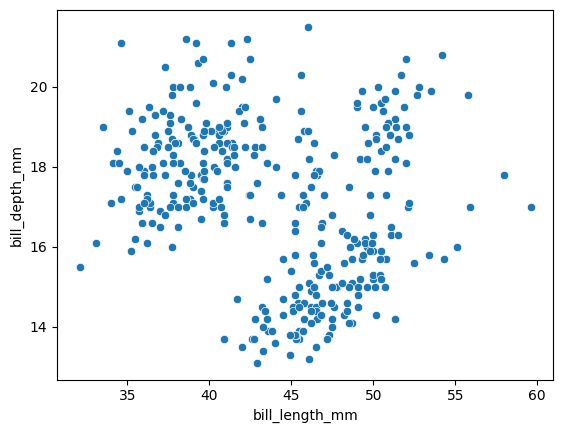

In [19]:
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm")

In [20]:
grafico = px.scatter(pinguinos, x="bill_length_mm", y="bill_depth_mm")
grafico.show()

In [21]:
# 4. Realiza un histograma con el dataset de pingüinos, usando la columna del tamaño de los picos. Utiliza las 4 librerías de Python.

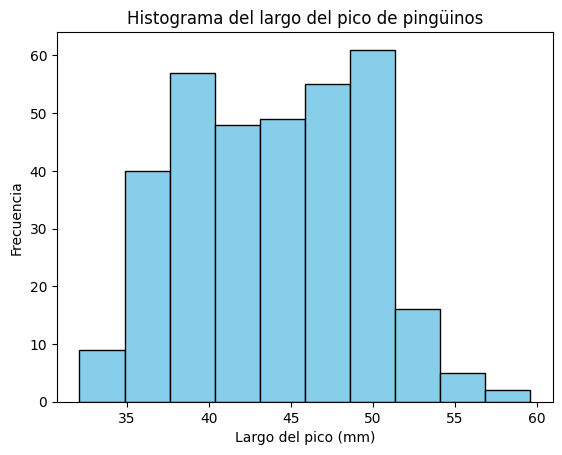

In [22]:
plt.hist(pinguinos["bill_length_mm"].dropna(), color='skyblue', edgecolor='black')
plt.title("Histograma del largo del pico de pingüinos")
plt.xlabel("Largo del pico (mm)")
plt.ylabel("Frecuencia")
plt.show()

In [23]:
# 5. Realiza un diagrama de cajas con el dataset de pingüinos, usando la columna del tamaño de los picos. Debes asegurarte de limpiar los datos antes de graficar.
# Utiliza las 4 librerías de Python.

In [38]:
data_cleaned = pinguinos['bill_length_mm'].dropna().count()
#print("Valores válidos:", pinguinos['bill_length_mm'].dropna().count())
#pinguinos['bill_length_mm'].isna().sum()

np.int64(2)

Text(0.5, 1.0, 'Diagrama de Cajas del Largo del Pico')

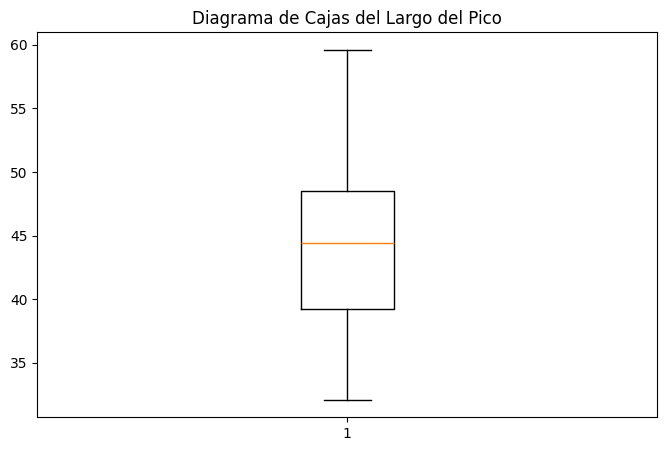

In [25]:
data_cleaned = pinguinos['bill_length_mm'].dropna()

# 1. Matplotlib
plt.figure(figsize=(8, 5))
plt.boxplot(data_cleaned)
plt.title('Diagrama de Cajas del Largo del Pico')

In [26]:
# 6. Realiza un gráfico circular o de torta, utilizando el dataset del Titanic, hallando el número de pasajeros por clase. Utiliza las 4 librerías de Python.

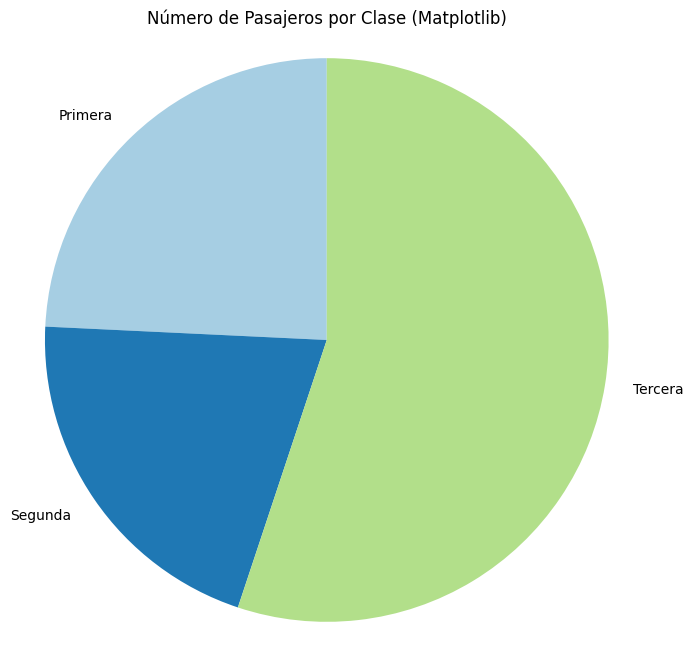

In [27]:
pasajeros_por_clase = titanic['pclass'].value_counts().sort_index()
class_labels = {1: 'Primera', 2: 'Segunda', 3: 'Tercera'}
display_labels = [class_labels[pclass] for pclass in pasajeros_por_clase.index]
plt.figure(figsize=(8, 8))
plt.pie(pasajeros_por_clase, labels=display_labels, startangle=90, colors=plt.cm.Paired.colors)
plt.title('Número de Pasajeros por Clase (Matplotlib)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()